# Module 6 Code Exercise

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly_express as px
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist
import scipy.cluster.hierarchy as sch

In [ ]:
data_dir = "C:\\Users\\psmal\\OneDrive\\UVA MSDS\\DS 5001\\ETA\\Module 6\\"

count_method = 'n' # 'c' or 'n' # n = n tokens, c = distinct token (term) count
tf_method = 'sum' # sum, max, log, double_norm, raw, binary
tf_norm_k = .5 # only used for double_norm
idf_method = 'standard' # standard, max, smooth
gradient_cmap = 'YlGnBu' # YlGn, GnBu, YlGnBu; For tables; see https://matplotlib.org/3.1.0/tutorials/colors/colormaps.html 

OHCO = ['book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']
SENTS = OHCO[:4]
PARAS = OHCO[:3]
CHAPS = OHCO[:2]
BOOKS = OHCO[:1]

bag = BOOKS

sns.set()
%matplotlib inline

LIB = pd.read_csv(data_dir + "LIB-1.csv").set_index(BOOKS)
TOKEN = pd.read_csv(data_dir + 'TOKEN.csv').set_index(OHCO)
VOCAB = pd.read_csv(data_dir + 'VOCAB.csv').set_index('term_id')
DOC = pd.read_csv(data_dir + "DOC.csv").set_index(PARAS)

VOCAB = VOCAB[~VOCAB.term_str.isna()]
TOKEN = TOKEN[~TOKEN.term_str.isna()]

TOKEN['term_id'] = TOKEN.term_str.map(VOCAB.reset_index().set_index('term_str').term_id)
VOCAB['pos_max'] = TOKEN.groupby(['term_id', 'pos']).pos.count().unstack().idxmax(1)

In [6]:
year_map = {
    158: 1815,   # Emma
    946: 1794,   # Lady Susan
    1212: 1790,  # Love And Freindship And Other Early Works
    141: 1814,   # Mansfield Park
    121: 1803,   # Northanger Abbey
    105: 1818,   # Persuasion
    1342: 1813,  # Pride and Prejudice
    161: 1811    # Sense and Sensibility
}

LIB['year'] = LIB.index.get_level_values('book_id').map(year_map)

In [7]:
AUSTEN_IDS = sorted(year_map.keys())
LIB_AUSTEN = LIB.loc[LIB.index.get_level_values('book_id').isin(AUSTEN_IDS)].copy()
LIB_AUSTEN = LIB_AUSTEN.sort_index()
LIB_AUSTEN

,book_title,book_file,author,title,year
book_id,,,,,
105,"Persuasion, by Jane Austen",epubs/AUSTEN_JANE_PERSUASION-pg105.txt,austen,Persuasion,1818.0
121,"Northanger Abbey, by Jane Austen",epubs/AUSTEN_JANE_NORTHANGER_ABBEY-pg121.txt,austen,Northanger Abbey,1803.0
141,"Mansfield Park, by Jane Austen",epubs/AUSTEN_JANE_MANSFIELD_PARK-pg141.txt,austen,Mansfield Park,1814.0
158,"Emma, by Jane Austen",epubs/AUSTEN_JANE_EMMA-pg158.txt,austen,Emma,1815.0
161,"Sense and Sensibility, by Jane Austen",epubs/AUSTEN_JANE_SENSE_AND_SENSIBILITY-pg161.txt,austen,Sense and Sensibility,1811.0
946,"Lady Susan, by Jane Austen",epubs/AUSTEN_JANE_LADY_SUSAN-pg946.txt,austen,Lady Susan,1794.0
1212,"Love And Freindship And Other Early Works, by ...",epubs/AUSTEN_JANE_LOVE_AND_FREINDSHIP_SIC_-pg1...,austen,Love And Freindship And Other Early Works,1790.0
1342,"Pride and Prejudice, by Jane Austen",epubs/AUSTEN_JANE_PRIDE_AND_PREJUDICE-pg1342.txt,austen,Pride and Prejudice,1813.0


In [8]:
TOKEN_AUSTEN = TOKEN.loc[TOKEN.index.get_level_values('book_id').isin(AUSTEN_IDS)].copy()
TOKEN_AUSTEN.shape

(780588, 5)

In [9]:
VOCAB_AUSTEN = TOKEN_AUSTEN['term_str'].value_counts().to_frame('n')
VOCAB_AUSTEN.index.name = 'term_str'
VOCAB_AUSTEN['term_id'] = range(len(VOCAB_AUSTEN))
VOCAB_AUSTEN = VOCAB_AUSTEN.reset_index().set_index('term_id')
VOCAB_AUSTEN.head()

,term_str,n
term_id,,
0,the,28259
1,to,26028
2,and,24054
3,of,22911
4,a,14298


In [11]:
termid_map = VOCAB_AUSTEN.reset_index().set_index('term_str')['term_id']
TOKEN_AUSTEN['term_id'] = TOKEN_AUSTEN['term_str'].map(termid_map)
VOCAB_AUSTEN['pos_max'] = TOKEN_AUSTEN.groupby(['term_id', 'pos']).pos.count().unstack().idxmax(1)

In [12]:
# get_tfidf() from previous module

def get_tfidf(token_df, bag, count_method='n', tf_method='sum', idf_method='standard'):
    """
    Compute a TFIDF matrix from a TOKEN dataframe.

    Parameters
    ----------
    token_df     : pd.DataFrame — TOKEN table with OHCO multi-index and term_id column
    bag          : list        — OHCO levels defining the document unit, e.g. BOOKS or CHAPS
    count_method : str         — 'n' for raw token counts, 'c' for binary (term present/absent)
    tf_method    : str         — how to normalize TF: 'sum', 'max', 'log', 'raw', 'binary'
    idf_method   : str         — how to compute IDF: 'standard', 'max', 'smooth'

    Returns
    -------
    TFIDF : pd.DataFrame — matrix of shape (n_docs x n_terms)
    """

    BOW = (
        token_df
        .groupby(bag + ['term_id'])
        .term_id.count()
        .to_frame()
        .rename(columns={'term_id': 'n'})
    )
    BOW['c'] = BOW.n.astype('bool').astype('int')

    DTCM = BOW[count_method].unstack().fillna(0).astype('int')

    if tf_method == 'sum':
        TF = (DTCM.T / DTCM.T.sum()).T

    elif tf_method == 'max':
        TF = (DTCM.T / DTCM.T.max()).T

    elif tf_method == 'log':
        TF = np.log10(1 + DTCM)

    elif tf_method == 'raw':
        TF = DTCM

    elif tf_method == 'binary':
        TF = DTCM.astype('bool').astype('int')

    else:
        raise ValueError(f"Unknown tf_method: '{tf_method}'. "
                         f"Choose from: 'sum', 'max', 'log', 'raw', 'binary'")

    N  = DTCM.shape[0]
    DF = DTCM[DTCM > 0].count()

    if idf_method == 'standard':
        IDF = np.log10(N / DF)

    elif idf_method == 'max':
        IDF = np.log10(DF.max() / DF)

    elif idf_method == 'smooth':
        IDF = np.log10((1 + N) / (1 + DF)) + 1

    else:
        raise ValueError(f"Unknown idf_method: '{idf_method}'. "
                         f"Choose from: 'standard', 'max', 'smooth'")

    TFIDF = TF * IDF

    return TFIDF

In [13]:
TFIDF_AUSTEN = get_tfidf(
    token_df     = TOKEN_AUSTEN,
    bag          = BOOKS,
    count_method = 'n',
    tf_method    = 'sum',
    idf_method   = 'standard'
)

TFIDF_AUSTEN.head()

term_id,0,1,2,3,4,5,6,7,8,9,...,14717,14718,14719,14720,14721,14722,14723,14724,14725,14726
book_id,,,,,,,,,,,,,,,,,,,,,
105,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
121,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
141,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
158,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
161,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008


In [20]:
print("TOKEN_AUSTEN shape:", TOKEN_AUSTEN.shape)
print("VOCAB_AUSTEN shape:", VOCAB_AUSTEN.shape)
print("TFIDF_AUSTEN shape:", TFIDF_AUSTEN.shape)

TOKEN_AUSTEN shape: (780588, 5)
VOCAB_AUSTEN shape: (14727, 3)
TFIDF_AUSTEN shape: (8, 14727)


In [14]:
DOC_AUSTEN = pd.DataFrame(index=TFIDF_AUSTEN.index)
DOC_AUSTEN.index.name = 'book_id'

DOC_AUSTEN['title'] = DOC_AUSTEN.index.map(LIB_AUSTEN['title'])
DOC_AUSTEN['year'] = DOC_AUSTEN.index.map(LIB_AUSTEN['year'])
DOC_AUSTEN['label'] = DOC_AUSTEN['title'] + ' (' + DOC_AUSTEN['year'].astype(str) + ')'

DOC_AUSTEN

,title,year,label
book_id,,,
105,Persuasion,1818.0,Persuasion (1818.0)
121,Northanger Abbey,1803.0,Northanger Abbey (1803.0)
141,Mansfield Park,1814.0,Mansfield Park (1814.0)
158,Emma,1815.0,Emma (1815.0)
161,Sense and Sensibility,1811.0,Sense and Sensibility (1811.0)
946,Lady Susan,1794.0,Lady Susan (1794.0)
1212,Love And Freindship And Other Early Works,1790.0,Love And Freindship And Other Early Works (179...
1342,Pride and Prejudice,1813.0,Pride and Prejudice (1813.0)


In [15]:
L0 = TFIDF_AUSTEN.astype(bool).astype(int)
L1 = TFIDF_AUSTEN.div(TFIDF_AUSTEN.sum(axis=1).replace(0, 1), axis=0)
L2 = TFIDF_AUSTEN.div(np.sqrt((TFIDF_AUSTEN**2).sum(axis=1)).replace(0, 1), axis=0)

In [16]:
DIST = {}
DIST['euclidean'] = pdist(TFIDF_AUSTEN, 'euclidean')
DIST['cityblock'] = pdist(TFIDF_AUSTEN, 'cityblock')
DIST['cosine'] = pdist(TFIDF_AUSTEN, 'cosine')
DIST['jaccard'] = pdist(L0, 'jaccard')
DIST['dice'] = pdist(L0, 'dice')
DIST['jensenshannon'] = pdist(L1, 'jensenshannon')
DIST['euclidean_L2'] = pdist(L2, 'euclidean')
DIST['canberra'] = pdist(TFIDF_AUSTEN, 'canberra')

In [17]:
def plot_dendrogram(dist_vec, labels, method='average', title='Dendrogram'):
    Z = sch.linkage(dist_vec, method=method)
    plt.figure(figsize=(12, 6))
    sch.dendrogram(
        Z,
        labels=labels,
        leaf_rotation=90,
        leaf_font_size=10
    )
    plt.title(title)
    plt.ylabel('Distance')
    plt.tight_layout()
    plt.show()

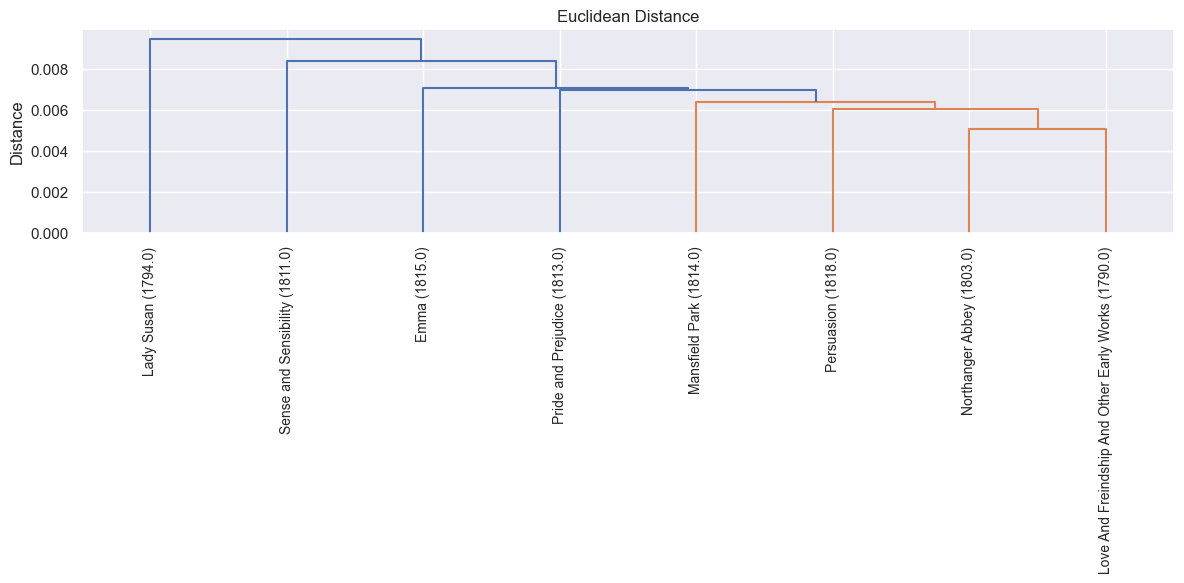

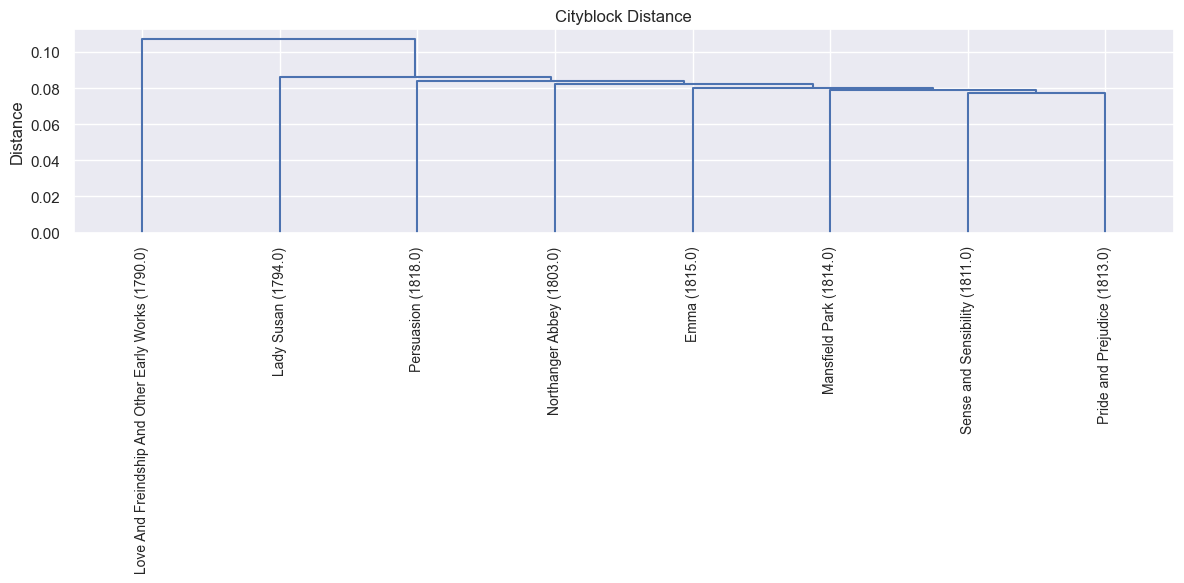

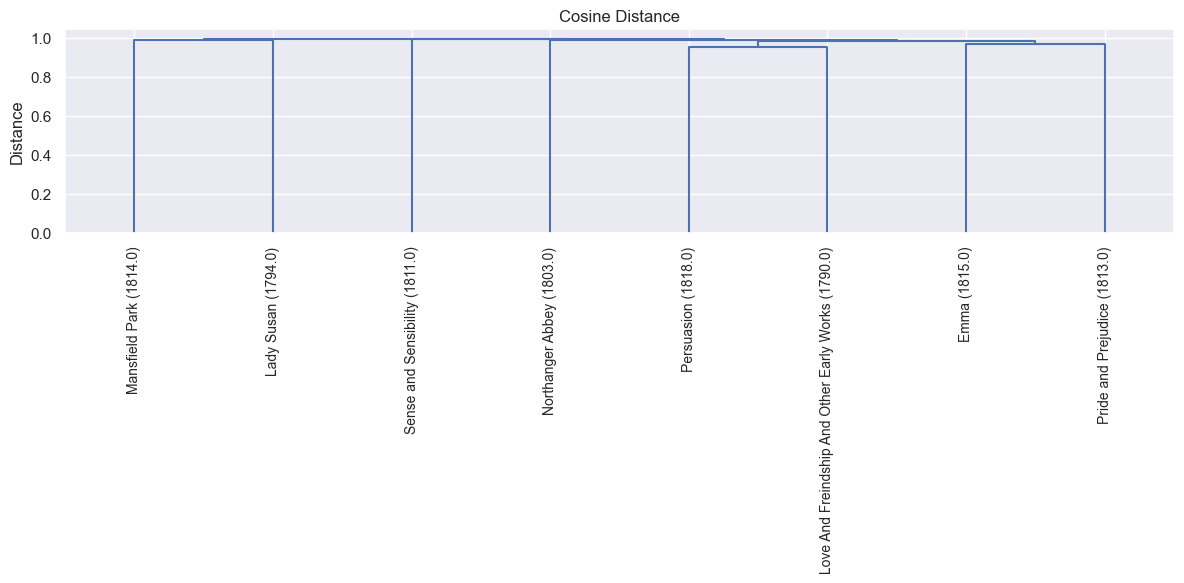

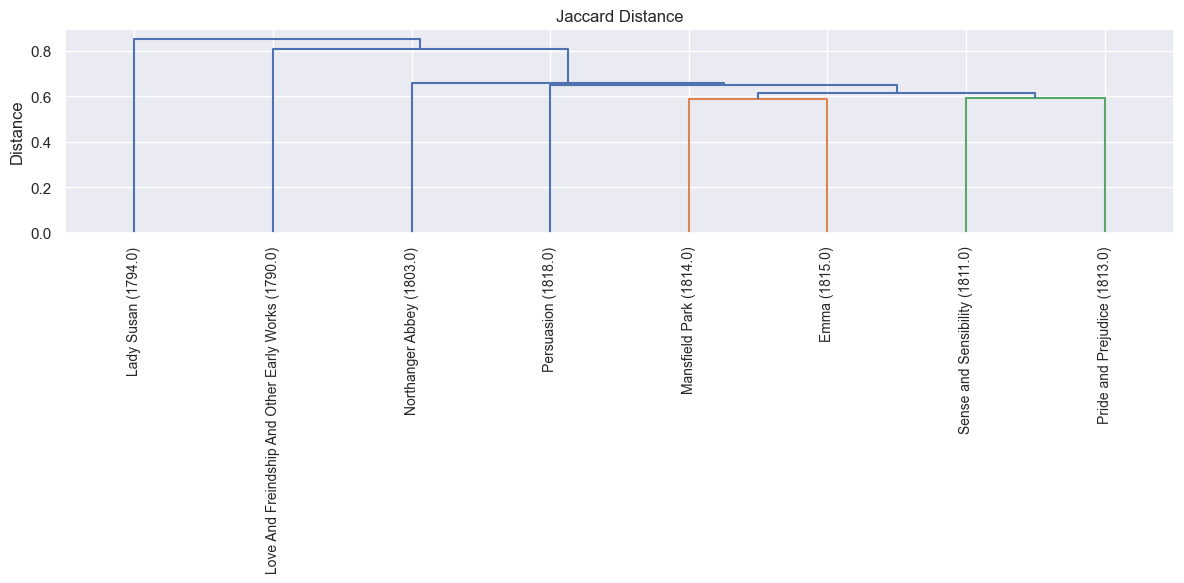

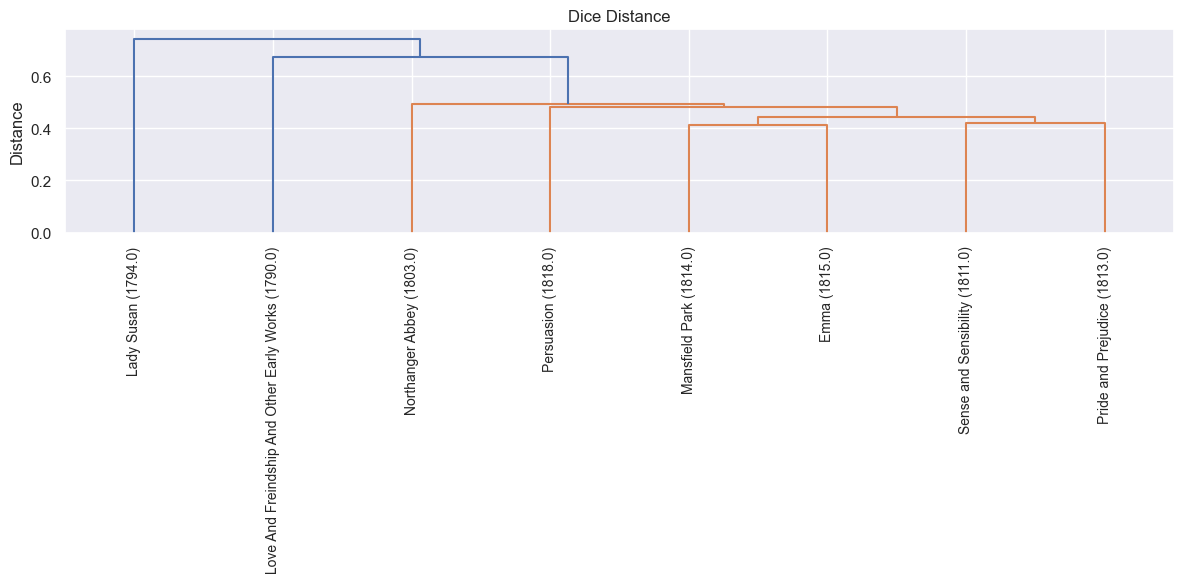

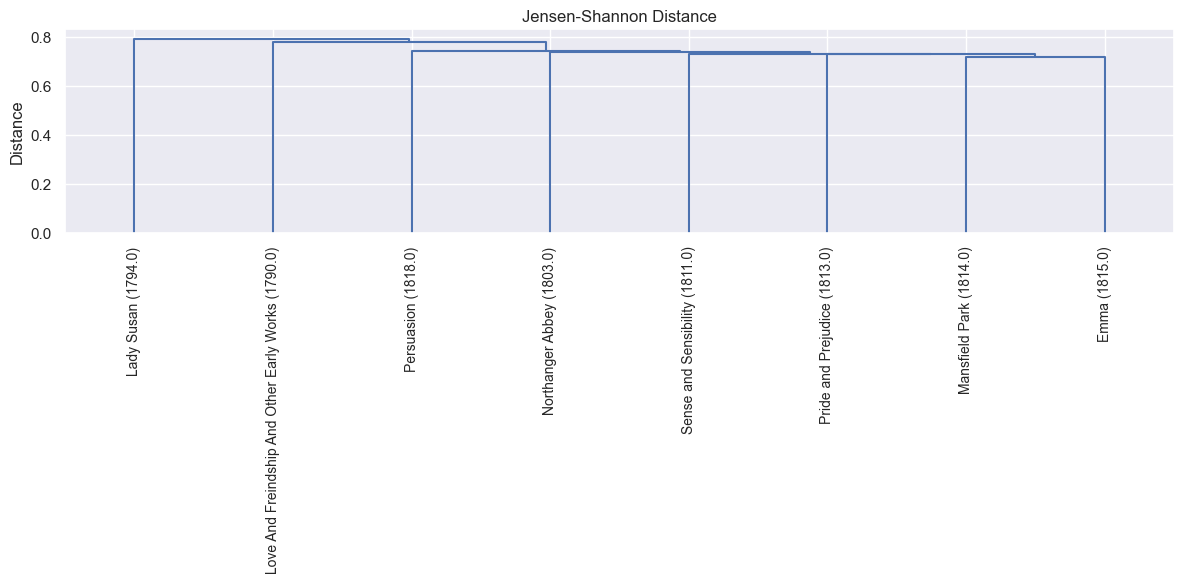

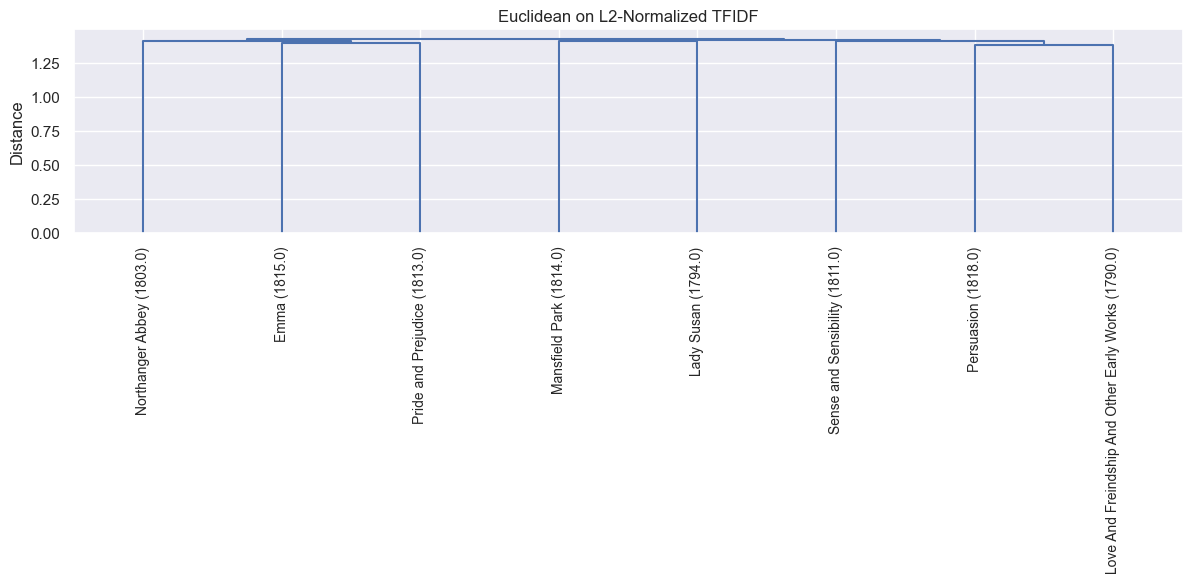

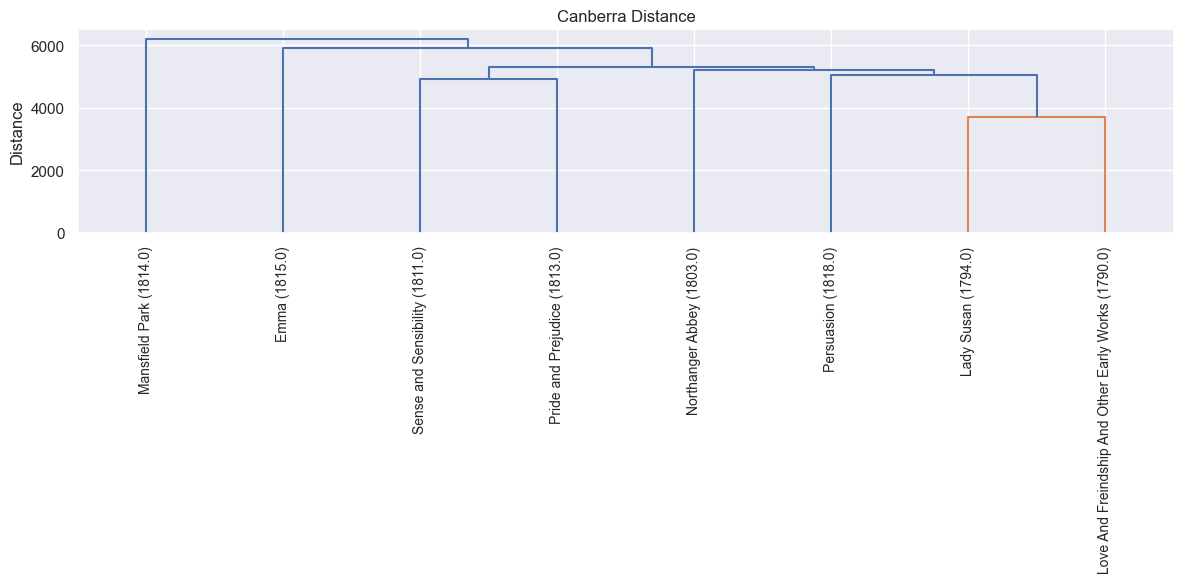

In [18]:
labels = DOC_AUSTEN['label'].tolist()

plot_dendrogram(DIST['euclidean'], labels, method='ward', title='Euclidean Distance')
plot_dendrogram(DIST['cityblock'], labels, method='average', title='Cityblock Distance')
plot_dendrogram(DIST['cosine'], labels, method='average', title='Cosine Distance')
plot_dendrogram(DIST['jaccard'], labels, method='average', title='Jaccard Distance')
plot_dendrogram(DIST['dice'], labels, method='average', title='Dice Distance')
plot_dendrogram(DIST['jensenshannon'], labels, method='average', title='Jensen-Shannon Distance')
plot_dendrogram(DIST['euclidean_L2'], labels, method='ward', title='Euclidean on L2-Normalized TFIDF')
plot_dendrogram(DIST['canberra'], labels, method='average', title='Canberra Distance')

# Which dendrogram performed best at grouping the works by year?

The Dice, Jaccard, and canberra dendrograms preformed well in seperating the early and later novels. However, the Dice dendrogram performed the best by clustering the early works together and the later works together. Metrics such as cosine distance, cityblcok, Jensen–Shannon distance, and Euclidean distance on L2-normalized vectors produced relatively flat dendrograms where most works merged at similar distances, making chronological interpretation difficult. 